In [ ]:
import pandas as pd
from pathlib import Path
import os
# Directory for all CSV outputs
OUT_DIR = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)
# Canonical path for merged dataset (now saved inside outputs)
MERGED_CSV = OUT_DIR / 'merged_data.csv'

# --- Monkeypatch pandas to redirect CSV writes/reads to OUT_DIR when plain filenames are used ---
_orig_to_csv = pd.DataFrame.to_csv
def _to_csv_outdir(self, path_or_buf=None, *args, **kwargs):
    # if a simple filename (no directory) was provided, save inside OUT_DIR
    if isinstance(path_or_buf, str):
        p = Path(path_or_buf)
        if not p.parent or p.parent == Path('.'):  # plain filename
            path_or_buf = OUT_DIR / p.name
    return _orig_to_csv(self, path_or_buf, *args, **kwargs)
pd.DataFrame.to_csv = _to_csv_outdir

_orig_read_csv = pd.read_csv
def _read_csv_inject(path, *args, **kwargs):
    # if code tries to read 'merged_data.csv' use the version in OUT_DIR
    if isinstance(path, str) and Path(path).name == 'merged_data.csv':
        path = MERGED_CSV
    return _orig_read_csv(path, *args, **kwargs)
pd.read_csv = _read_csv_inject

In [ ]:
# CSV outputs directory check
print(f"CSV outputs will be saved to: {OUT_DIR}")
print("Existing CSV files in outputs folder:")
for p in OUT_DIR.glob('*.csv'):
    print('-', p.name)

## *Data Cleaning on Transactions*

In [3]:
transaction_df = pd.read_excel('QVI_transaction_data.xlsx')

transaction_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [4]:
transaction_df.shape

(264836, 8)

In [5]:
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [6]:
transaction_df.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [7]:
duplicates = transaction_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 1


In [8]:
transaction_df = transaction_df.drop_duplicates()

print(f"Shape after removing duplicates : {transaction_df.shape}")

Shape after removing duplicates : (264835, 8)


In [9]:
negative_qty = (transaction_df['PROD_QTY'] <= 0).sum()
negative_sales = (transaction_df['TOT_SALES'] <= 0).sum()
print(f"Negative or zero PROD_QTY: {negative_qty}")
print(f"Negative or zero TOT_SALES: {negative_sales}")

Negative or zero PROD_QTY: 0
Negative or zero TOT_SALES: 0


In [10]:
transaction_df[['PROD_QTY', 'TOT_SALES']].describe()

,PROD_QTY,TOT_SALES
count,264835.000000,264835.000000
mean,1.907308,7.304205
std,0.643655,3.083231
min,1.000000,1.500000
25%,2.000000,5.400000
50%,2.000000,7.400000
75%,2.000000,9.200000
max,200.000000,650.000000


In [11]:
# Calculate Q1, Q3, and IQR for PROD_QTY
Q1_qty = transaction_df['PROD_QTY'].quantile(0.25)
Q3_qty = transaction_df['PROD_QTY'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty
lower_bound_qty = Q1_qty - 1.5 * IQR_qty
upper_bound_qty = Q3_qty + 1.5 * IQR_qty

# Calculate for TOT_SALES
Q1_sales = transaction_df['TOT_SALES'].quantile(0.25)
Q3_sales = transaction_df['TOT_SALES'].quantile(0.75)
IQR_sales = Q3_sales - Q1_sales
lower_bound_sales = Q1_sales - 1.5 * IQR_sales
upper_bound_sales = Q3_sales + 1.5 * IQR_sales

#Count Outliers before flitering
outliers_qty = ((transaction_df['PROD_QTY'] < lower_bound_qty) | (transaction_df['PROD_QTY'] > upper_bound_qty)).sum()
outliers_sales = ((transaction_df['TOT_SALES'] < lower_bound_sales) | (transaction_df['TOT_SALES'] > upper_bound_sales)).sum()
print(f"Outliers in PROD_QTY: {outliers_qty}")
print(f"Outliers in TOT_SALES: {outliers_sales}")

# Filter out outliers
transaction_df = transaction_df[
    (transaction_df['PROD_QTY'] >= lower_bound_qty) & (transaction_df['PROD_QTY'] <= upper_bound_qty) &
    (transaction_df['TOT_SALES'] >= lower_bound_sales) & (transaction_df['TOT_SALES'] <= upper_bound_sales)
]
print(f"Shape after removing outliers: {transaction_df.shape}")

Outliers in PROD_QTY: 28797
Outliers in TOT_SALES: 578
Shape after removing outliers: (236038, 8)


In [12]:
# Convert DATE to datetime (only if not already converted)
if transaction_df['DATE'].dtype != 'datetime64[ns]':
    transaction_df['DATE'] = pd.to_datetime(transaction_df['DATE'], origin='1899-12-30', unit='D', errors='coerce')

# Check for invalid dates (NaT values)
invalid_dates = transaction_df['DATE'].isna().sum()
print(f"Invalid dates after conversion: {invalid_dates}")

# If many are invalid, inspect the original values
print(transaction_df['DATE'].head())  # Check converted dates
print(transaction_df['DATE'].min(), transaction_df['DATE'].max())  # Check date range

Invalid dates after conversion: 0
0    2018-10-17
2    2019-05-20
9    2018-08-18
12   2019-05-18
24   2018-08-15
Name: DATE, dtype: datetime64[ns]
2018-07-01 00:00:00 2019-06-30 00:00:00


In [13]:
transaction_df['DATE'].head(10)

0    2018-10-17
2    2019-05-20
9    2018-08-18
12   2019-05-18
24   2018-08-15
26   2018-08-19
32   2019-05-20
38   2018-08-18
53   2019-05-19
57   2019-05-14
Name: DATE, dtype: datetime64[ns]

Unique product names: 114


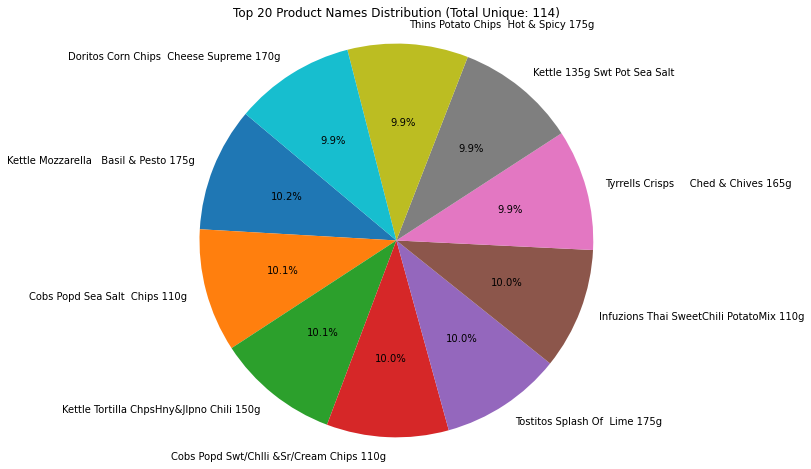

In [14]:
import matplotlib.pyplot as plt
unique_prod_names = transaction_df['PROD_NAME'].nunique()
print(f"Unique product names: {unique_prod_names}")
# Inspect a sample for irregularities
top_20_prod = transaction_df['PROD_NAME'].value_counts().head(10)

#Create a pie chart for this visualization
plt.figure(figsize=(10,8))
plt.pie(top_20_prod.values, labels=top_20_prod.index, autopct='%1.1f%%', startangle=140)
plt.title(f'Top 20 Product Names Distribution (Total Unique: {unique_prod_names})')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


## *Data Cleaning on Customers*

In [15]:
import pandas as pd

customers_df = pd.read_csv('QVI_purchase_behaviour.csv')

customers_df.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [16]:
customers_df.shape

(72637, 3)

In [17]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [18]:
customers_df.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

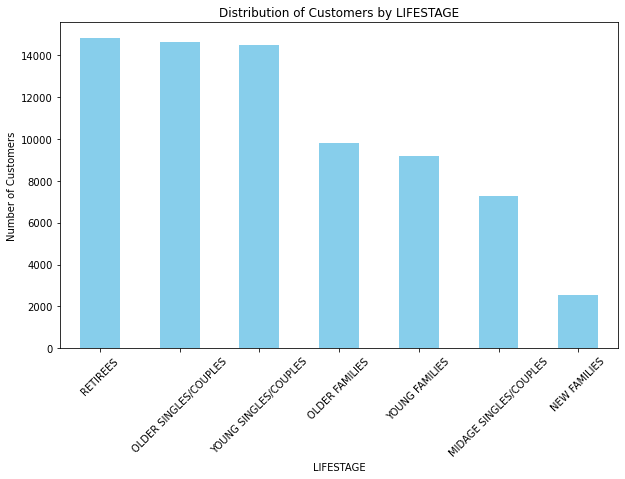

In [19]:
import matplotlib.pyplot as plt

lifestage_count = customers_df['LIFESTAGE'].value_counts()

plt.figure(figsize=(10,6))
lifestage_count.plot(kind='bar', color = 'skyblue')
plt.title('Distribution of Customers by LIFESTAGE')
plt.xlabel('LIFESTAGE')
plt.ylabel('Number of Customers')
plt.xticks(rotation = 45)
plt.show()


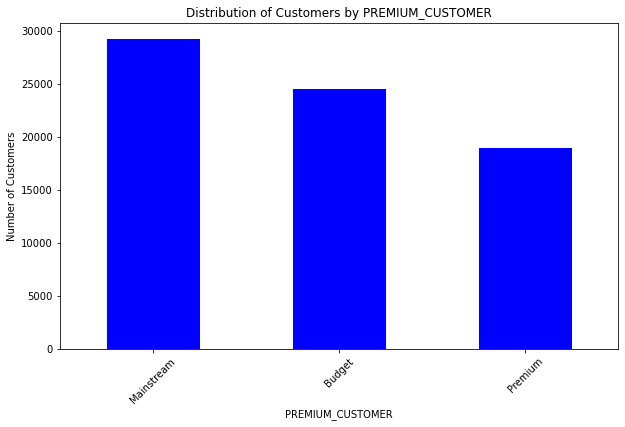

In [20]:
import matplotlib.pyplot as plt

premium_customers_count = customers_df['PREMIUM_CUSTOMER'].value_counts()

plt.figure(figsize=(10,6))
premium_customers_count.plot(kind = 'bar',color = 'blue')
plt.title('Distribution of Customers by PREMIUM_CUSTOMER')
plt.xlabel('PREMIUM_CUSTOMER')
plt.ylabel('Number of Customers')
plt.xticks(rotation = 45)
plt.show()


## *Data Merging*

In [21]:
customers_df = pd.read_csv('QVI_purchase_behaviour.csv')
transaction_df = pd.read_excel('QVI_transaction_data.xlsx')

In [ ]:
# In the "Data Merging" section, after reloading:
customers_df = pd.read_csv('QVI_purchase_behaviour.csv')
transaction_df = pd.read_excel('QVI_transaction_data.xlsx')

# Add this: Convert DATE if not already datetime
if transaction_df['DATE'].dtype != 'datetime64[ns]':
    transaction_df['DATE'] = pd.to_datetime(transaction_df['DATE'], origin='1899-12-30', unit='D', errors='coerce')

merged_df = pd.merge(transaction_df, customers_df, on ='LYLTY_CARD_NBR', how = 'left')

merged_df = merged_df.drop_duplicates()

#validate the merge dataset
print("Merge Dataframe shape: ", merged_df.shape)
print("Checking any null values in merged dataframe")
print(merged_df.isnull().sum())

#Making sure if there is no duplicates in merged dataframe
duplicates = merged_df.duplicated().sum()
print(f'Number of duplicates rows in merged Dataframe: {duplicates}')


# check for the unmatched records (Rows where customer data is missing)
unmatched = merged_df['LIFESTAGE'].isnull().sum()
print(f'Number of unmatched records by checking if there is a missing customer data : {unmatched}')

# Save the merged dataset
merged_df.to_csv('merged_data.csv', index=False)
print(f"Merged dataset saved to {MERGED_CSV}")

Merge Dataframe shape:  (264835, 10)
Checking any null values in merged dataframe
DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64
Number of duplicates rows in merged Dataframe: 0
Number of unmatched records by checking if there is a missing customer data : 0
Merged dataset saved as 'merged_data.csv'


In [23]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 264835 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              264835 non-null  datetime64[ns]
 1   STORE_NBR         264835 non-null  int64         
 2   LYLTY_CARD_NBR    264835 non-null  int64         
 3   TXN_ID            264835 non-null  int64         
 4   PROD_NBR          264835 non-null  int64         
 5   PROD_NAME         264835 non-null  object        
 6   PROD_QTY          264835 non-null  int64         
 7   TOT_SALES         264835 non-null  float64       
 8   LIFESTAGE         264835 non-null  object        
 9   PREMIUM_CUSTOMER  264835 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 22.2+ MB


In [24]:
merged_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


## *Descriptive Analysis on Chips Dataset*

In [25]:
import pandas as pd

merged_df = pd.read_csv('merged_data.csv')

# # Verify the loaded data
# print("Loaded merged DataFrame shape:", merged_df.shape)
# print("Null values in loaded DataFrame:")
# print(merged_df.isnull().sum())



In [26]:
#1. Total sales

total_sales_overall = merged_df['TOT_SALES'].sum()
print(f"Total Sales Overall: {total_sales_overall}")
# 1.1 store
total_sales_by_store = merged_df.groupby('STORE_NBR')['TOT_SALES'].sum()
print("Total Sales by STORE_NBR")
print(total_sales_by_store.head())

#1.2 products
total_sales_by_prod = merged_df.groupby('PROD_NAME')['TOT_SALES'].sum()
print("Total Sales by PROD_NAME:")
print(total_sales_by_prod.head())

# lifestages of customers
total_sales_by_lifestage = merged_df.groupby('LIFESTAGE')['TOT_SALES'].sum()
print("Total Sales by LIFESTAGE:")
print(total_sales_by_lifestage)

# premimum customers
total_sales_by_premium = merged_df.groupby('PREMIUM_CUSTOMER')['TOT_SALES'].sum()
print("Total Sales by PREMIUM_CUSTOMER:")
print(total_sales_by_premium)

#2 total transactions
total_transactions = merged_df['TXN_ID'].nunique()
print(f"Total Transactions : {total_transactions}")

#3 Units sold
units_sold = merged_df['PROD_QTY'].sum()
print(f"Units sold : {units_sold}")

# 4. Average Transaction Value (ATV)
avg_transaction_value = total_sales_overall / total_transactions
print(f"Average Transaction Value (ATV): {avg_transaction_value}")

# 5. Average Spend per Product per Customer Segment
avg_spend_per_segment = merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].mean().unstack()
print("Average Spend per Customer Segment:")
print(avg_spend_per_segment)

# 6. Average Quantity Purchases per Transaction
avg_qty_per_transaction = merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PROD_QTY'].mean().unstack()
print("Average Quantity Purchases per Transaction by Segment:")
print(avg_qty_per_transaction)

# Optional: Average Quantity by Store
avg_qty_by_store = merged_df.groupby('STORE_NBR')['PROD_QTY'].mean()
print("Average Quantity Purchases per Transaction by STORE_NBR:")
print(avg_qty_by_store.head())


Total Sales Overall: 1934408.9999999998
Total Sales by STORE_NBR
STORE_NBR
1     2393.60
2     2005.80
3    12802.45
4    14647.65
5     9500.80
Name: TOT_SALES, dtype: float64
Total Sales by PROD_NAME:
PROD_NAME
Burger Rings 220g                 6831.0
CCs Nacho Cheese    175g          5961.9
CCs Original 175g                 6048.0
CCs Tasty Cheese    175g          6069.0
Cheetos Chs & Bacon Balls 190g    9243.3
Name: TOT_SALES, dtype: float64
Total Sales by LIFESTAGE:
LIFESTAGE
MIDAGE SINGLES/COUPLES    184751.30
NEW FAMILIES               50433.45
OLDER FAMILIES            353767.20
OLDER SINGLES/COUPLES     402420.75
RETIREES                  366470.90
YOUNG FAMILIES            316160.10
YOUNG SINGLES/COUPLES     260405.30
Name: TOT_SALES, dtype: float64
Total Sales by PREMIUM_CUSTOMER:
PREMIUM_CUSTOMER
Budget        676211.55
Mainstream    750744.50
Premium       507452.95
Name: TOT_SALES, dtype: float64
Total Transactions : 263127
Units sold : 505122
Average Transaction Value (A

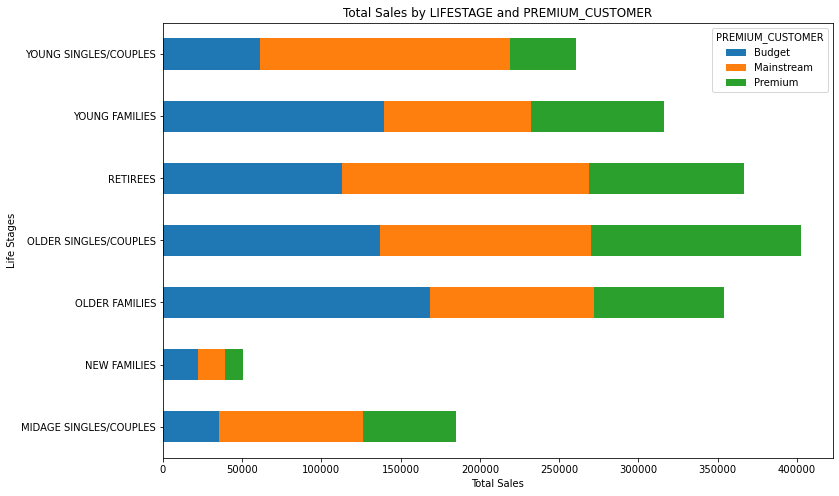

In [27]:
import matplotlib.pyplot as plt

import seaborn as sns

# Load the merged data if not already loaded
merged_df = pd.read_csv('merged_data.csv')

# Ensure DATE is datetime
merged_df['DATE'] = pd.to_datetime(merged_df['DATE'])

# 1. Bar Chart: Total Sales by LIFESTAGE and PREMIUM_CUSTOMER
sales_by_segment = merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().unstack()
sales_by_segment.plot(kind='barh', figsize=(12, 8), stacked=True)
plt.title('Total Sales by LIFESTAGE and PREMIUM_CUSTOMER')
plt.xlabel('Total Sales')
plt.ylabel('Life Stages')
plt.legend(title='PREMIUM_CUSTOMER')
plt.show()



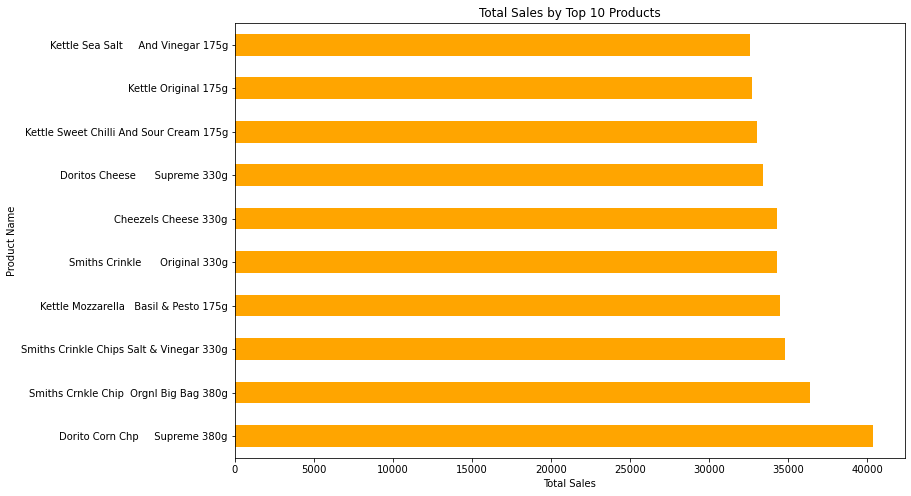

In [28]:
# 2. Bar Chart: Total Sales by Top 10 PROD_NAME
top_10_prod = merged_df.groupby('PROD_NAME')['TOT_SALES'].sum().nlargest(10)
top_10_prod.plot(kind='barh', figsize=(12, 8), color='orange')
plt.title('Total Sales by Top 10 Products')
plt.xlabel('Total Sales')  # Now on x-axis
plt.ylabel('Product Name')
plt.show()

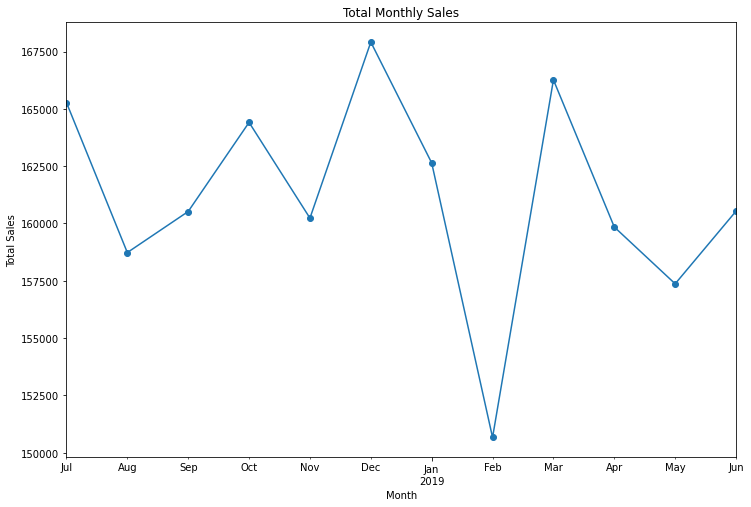

In [29]:
# 3. Line Chart: Total Monthly Sales
monthly_sales = merged_df.groupby(merged_df['DATE'].dt.to_period('M'))['TOT_SALES'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()
monthly_sales.plot(kind='line', figsize=(12, 8), marker='o')
plt.title('Total Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

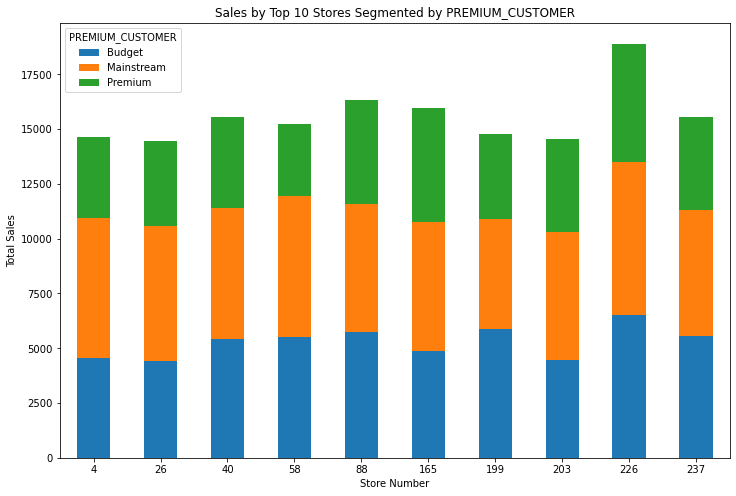

In [30]:

# 4. Stacked Bar Chart: Sales by STORE_NBR Segmented by PREMIUM_CUSTOMER (Top 10 Stores)
top_10_stores = merged_df.groupby('STORE_NBR')['TOT_SALES'].sum().nlargest(10).index
store_segment_sales = merged_df[merged_df['STORE_NBR'].isin(top_10_stores)].groupby(['STORE_NBR', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().unstack()
store_segment_sales.plot(kind='bar', figsize=(12, 8), stacked=True)
plt.title('Sales by Top 10 Stores Segmented by PREMIUM_CUSTOMER')
plt.xlabel('Store Number')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.legend(title='PREMIUM_CUSTOMER')
plt.show()

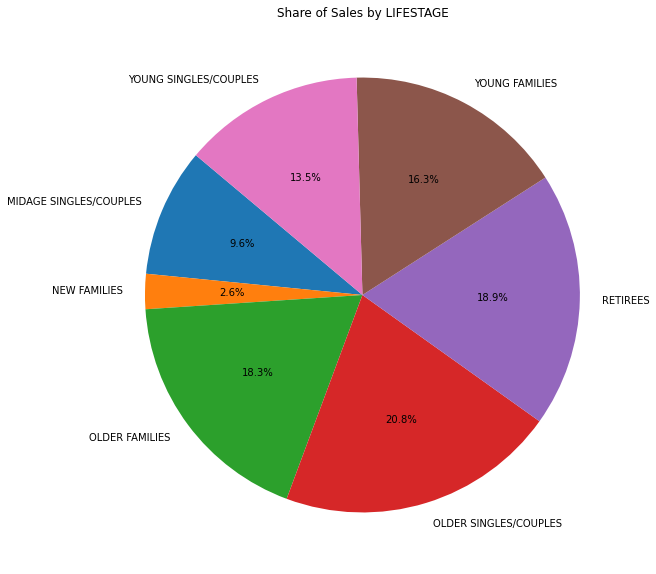

In [31]:
# 5. Pie Chart: Share of Sales by LIFESTAGE
lifestage_sales = merged_df.groupby('LIFESTAGE')['TOT_SALES'].sum()
lifestage_sales.plot(kind='pie', figsize=(10, 10), autopct='%1.1f%%', startangle=140)
plt.title('Share of Sales by LIFESTAGE')
plt.ylabel('')
plt.show()

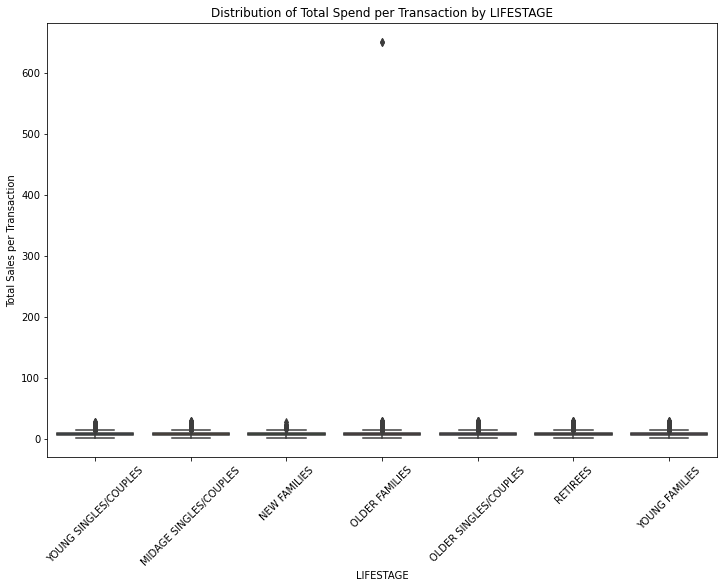

In [32]:
# 6. Box Plot: Distribution of Total Spend per Transaction by LIFESTAGE
plt.figure(figsize=(12, 8))
sns.boxplot(data=merged_df, x='LIFESTAGE', y='TOT_SALES')
plt.title('Distribution of Total Spend per Transaction by LIFESTAGE')
plt.xlabel('LIFESTAGE')
plt.ylabel('Total Sales per Transaction')
plt.xticks(rotation=45)
plt.show()

## *Feature Engineering*

### **Create and Standardise BRAND Feature**

- Loads merged data and checks if BRAND column exists; if not, extracts brand from PROD_NAME.
- Normalizes casing and handles numeric starts.
- Inspects top brands and low-frequency entries for inconsistencies.
- Applies manual mapping to standardize brand names (e.g., "Dorito" to "Doritos").
- Performs QA by checking changes and final counts.
- Saves the updated dataframe with the BRAND column.

In [ ]:
# filepath: c:\Personal\Work\Quantium_DataAnalysis_Project\Data Analysis First Section.ipynb

import pandas as pd
import re

# Load merged data if not already loaded
merged_df = pd.read_csv('merged_data.csv')

# Extract brand name (first word of PROD_NAME)
if 'BRAND' not in merged_df.columns:
    merged_df['BRAND_RAW'] = (
        merged_df['PROD_NAME'].astype(str).str.split().str[0]
        .str.replace(r'[^\w&]', '', regex=True).str.strip()
    )
    mask_numeric_first = merged_df['BRAND_RAW'].str.match(r'^\d', na=False)
    merged_df.loc[mask_numeric_first, 'BRAND_RAW'] = merged_df.loc[mask_numeric_first, 'PROD_NAME'] \
        .str.split().str[1].str.replace(r'[^\w&]', '', regex=True).str.strip()
    merged_df['BRAND'] = merged_df['BRAND_RAW'].str.title().fillna('Unknown')

# 3) Inspect frequency to identify inconsistencies
print("Top brands (initial):")
print(merged_df['BRAND'].value_counts().head(50))
print("\nLow-frequency candidates for review (<=10 occurrences):")
print(merged_df['BRAND'].value_counts().loc[lambda x: x <= 10].sort_values())

# 4) Apply manual mapping to standardise known inconsistencies
brand_map = {
    'Dorito': 'Doritos',
    'Doritos': 'Doritos',
    'Smith': 'Smiths',
    'Rrd': 'RRD',
    'Red': 'RRD',
    'Infzns': 'Infuzions',
    'Infuzions': 'Infuzions',
    'Ww': 'Woolworths',
    'Woolworths': 'Woolworths',
    'Woolies': 'Woolworths',
}

merged_df['BRAND'] = merged_df['BRAND'].replace(brand_map)

# 5) Quick QA: check changed examples and final counts
print("\nExamples where BRAND_RAW != BRAND:")
print(merged_df.loc[merged_df['BRAND_RAW'] != merged_df['BRAND'], ['PROD_NAME', 'BRAND_RAW', 'BRAND']].head(20))

print("\nFinal top brands:")
print(merged_df['BRAND'].value_counts().head(50))
print("\nUnique brands:", merged_df['BRAND'].nunique())

# 6) Save updated dataframe (optional - overwrite merged file or save new)
merged_df.to_csv('merged_data.csv', index=False)
print(f"Saved {MERGED_CSV} with BRAND")


Top brands (initial):
Kettle        41288
Smiths        28859
Pringles      25102
Doritos       24962
Thins         14075
Rrd           11894
Infuzions     11057
Ww            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Old            9324
Tyrrells       6442
Grain          6272
Natural        6050
Red            5885
Cheezels       4603
Ccs            4551
Woolworths     4437
Dorito         3185
Infzns         3144
Smith          2963
Cheetos        2927
Snbts          1576
Burger         1564
Grnwves        1468
Sunbites       1432
Ncc            1419
French         1418
Name: BRAND, dtype: int64

Low-frequency candidates for review (<=10 occurrences):
Series([], Name: BRAND, dtype: int64)

Examples where BRAND_RAW != BRAND:
                                    PROD_NAME BRAND_RAW       BRAND
1                    CCs Nacho Cheese    175g       CCs         Ccs
13           WW Crinkle Cut      Chicken 175g        WW  Woolworths
15                          CCs Origi

### **Brand Behavior Segment**

- Loads merged data and ensures the BRAND column exists.
- Calculates total sales by brand overall, ranks them, and saves to CSV.
- Plots a bar chart for top 10 brands by total sales.
- Groups sales by brand within each lifestage and premium customer segment, identifies top 3 brands per segment, and saves results.
- Creates a heatmap showing sales of top 10 brands across segments.

Top 20 brands (overall):
         BRAND  TOTAL_SALES
10      Kettle     390239.8
5      Doritos     241890.9
16      Smiths     224654.2
14    Pringles     177655.5
9    Infuzions      99047.6
15         RRD      95046.0
13         Old      90785.1
19       Thins      88852.5
21    Twisties      81522.1
20    Tostitos      79789.6
4         Cobs      70569.8
22    Tyrrells      51647.4
23  Woolworths      49343.6
7        Grain      43048.8
3     Cheezels      40029.9
11     Natural      34272.0
1          Ccs      18078.9
2      Cheetos      16884.5
8      Grnwves       8568.4
12         Ncc       8046.0


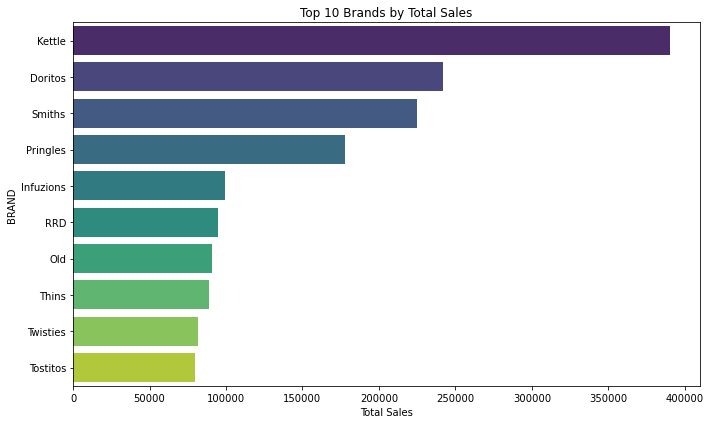


Top brands per (LIFESTAGE, PREMIUM_CUSTOMER) (sample):
                 LIFESTAGE PREMIUM_CUSTOMER    BRAND  TOTAL_SALES
0   MIDAGE SINGLES/COUPLES           Budget   Kettle      6736.20
1   MIDAGE SINGLES/COUPLES           Budget  Doritos      4553.60
2   MIDAGE SINGLES/COUPLES           Budget   Smiths      4251.30
3   MIDAGE SINGLES/COUPLES       Mainstream   Kettle     20231.80
4   MIDAGE SINGLES/COUPLES       Mainstream  Doritos     11117.65
5   MIDAGE SINGLES/COUPLES       Mainstream   Smiths     10173.10
6   MIDAGE SINGLES/COUPLES          Premium   Kettle     11390.20
7   MIDAGE SINGLES/COUPLES          Premium  Doritos      7054.35
8   MIDAGE SINGLES/COUPLES          Premium   Smiths      6724.30
9             NEW FAMILIES           Budget   Kettle      4731.60
10            NEW FAMILIES           Budget  Doritos      2934.85
11            NEW FAMILIES           Budget   Smiths      2335.40
12            NEW FAMILIES       Mainstream   Kettle      3847.00
13            NEW FA

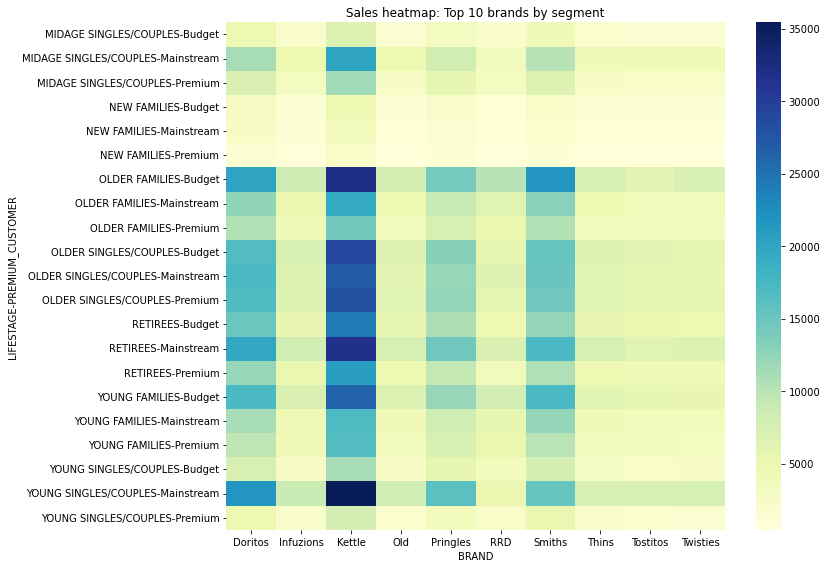

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load merged_df (assuming brand feature is already created)
merged_df = pd.read_csv('merged_data.csv')

# Ensure BRAND exists (if not, the previous cell should have created it)
if 'BRAND' not in merged_df.columns:
    raise ValueError("BRAND column not found. Run the brand creation cell first.")

# Fill any missing segments
merged_df['LIFESTAGE'] = merged_df['LIFESTAGE'].fillna('Unknown')
merged_df['PREMIUM_CUSTOMER'] = merged_df['PREMIUM_CUSTOMER'].fillna('Unknown')

# 1) Overall: total sales by brand (ranked)
total_sales_by_brand = (
    merged_df.groupby('BRAND')['TOT_SALES']
    .sum()
    .reset_index(name='TOTAL_SALES')
    .sort_values('TOTAL_SALES', ascending=False)
)
print("Top 20 brands (overall):")
print(total_sales_by_brand.head(20))

# Save overall brand sales
total_sales_by_brand.to_csv(OUT_DIR / 'brand_total_sales.csv', index=False)
# Quick plot: top 10 brands
plt.figure(figsize=(10,6))
sns.barplot(data=total_sales_by_brand.head(10), x='TOTAL_SALES', y='BRAND', palette='viridis')
plt.title('Top 10 Brands by Total Sales')
plt.xlabel('Total Sales')
plt.tight_layout()
plt.show()

# 2) By segment: total sales by brand within each (LIFESTAGE, PREMIUM_CUSTOMER)
seg_brand = (
    merged_df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER','BRAND'])['TOT_SALES']
    .sum()
    .reset_index(name='TOTAL_SALES')
)

# Get top 3 brands per segment
top_n = 3
top_brands_by_segment = (
    seg_brand.sort_values(['LIFESTAGE','PREMIUM_CUSTOMER','TOTAL_SALES'], ascending=[True,True,False])
    .groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])
    .head(top_n)
    .reset_index(drop=True)
)

print("\nTop brands per (LIFESTAGE, PREMIUM_CUSTOMER) (sample):")
print(top_brands_by_segment.head(40))

# Save segment-level results
top_brands_by_segment.to_csv('top_brands_by_segment.csv', index=False)
top_brands_by_segment.to_csv(OUT_DIR / 'top_brands_by_segment.csv', index=False)
seg_brand.to_csv(OUT_DIR / 'brand_sales_by_segment_full.csv', index=False)
# Optional: heatmap for top overall brands across segments
top10 = total_sales_by_brand['BRAND'].head(10).tolist()
pivot = (
    merged_df[merged_df['BRAND'].isin(top10)]
    .groupby(['LIFESTAGE','PREMIUM_CUSTOMER','BRAND'])['TOT_SALES']
    .sum()
    .reset_index()
    .pivot_table(index=['LIFESTAGE','PREMIUM_CUSTOMER'], columns='BRAND', values='TOT_SALES', fill_value=0)
)
plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title('Sales heatmap: Top 10 brands by segment')
plt.tight_layout()
plt.show()


Top brands gaining attention (by % change):
         BRAND  PCT_CHANGE  GAINING_ATTENTION
0       Burger    0.146667              False
11     Natural    0.085714              False
3     Cheezels    0.034326              False
1          Ccs    0.030203              False
23  Woolworths    0.028767              False
9    Infuzions    0.027312              False
19       Thins    0.010009              False
16      Smiths    0.008750              False
10      Kettle    0.005651              False
15         RRD    0.001800              False


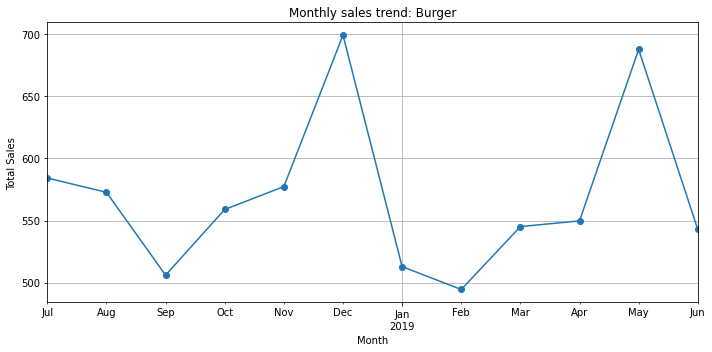

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

merged_df = pd.read_csv('merged_data.csv')
merged_df['DATE'] = pd.to_datetime(merged_df['DATE'])
merged_df['LIFESTAGE'] = merged_df['LIFESTAGE'].fillna('Unknown')
merged_df['PREMIUM_CUSTOMER'] = merged_df['PREMIUM_CUSTOMER'].fillna('Unknown')

# 1) Brand × segment summary (sales, units, unique customers, transactions)
brand_seg = (
    merged_df.groupby(['BRAND', 'LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .agg(
        TOTAL_SALES=('TOT_SALES', 'sum'),
        TOTAL_UNITS=('PROD_QTY', 'sum'),
        UNIQUE_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique'),
        TRANSACTIONS=('TXN_ID', 'nunique')
    )
    .reset_index()
)

# Brand totals for share calculation
brand_totals = brand_seg.groupby('BRAND')['TOTAL_SALES'].sum().reset_index(name='BRAND_TOTAL_SALES')
brand_seg = brand_seg.merge(brand_totals, on='BRAND', how='left')
brand_seg['SEG_SHARE_OF_BRAND'] = brand_seg['TOTAL_SALES'] / brand_seg['BRAND_TOTAL_SALES']
brand_seg['AVG_SPEND_PER_CUSTOMER'] = brand_seg['TOTAL_SALES'] / brand_seg['UNIQUE_CUSTOMERS'].replace(0, np.nan)

# Save for review
brand_seg.to_csv(OUT_DIR / 'brand_by_segment_summary.csv', index=False)
# 2) Top segment(s) for each brand by sales and by avg spend
top_by_sales = (
    brand_seg.sort_values(['BRAND','TOTAL_SALES'], ascending=[True, False])
    .groupby('BRAND')
    .head(1)
    .reset_index(drop=True)
    .rename(columns={'LIFESTAGE':'TOP_LIFESTAGE_BY_SALES','PREMIUM_CUSTOMER':'TOP_PREMIUM_BY_SALES','TOTAL_SALES':'TOP_SALES'})
)
top_by_spend = (
    brand_seg.sort_values(['BRAND','AVG_SPEND_PER_CUSTOMER'], ascending=[True, False])
    .groupby('BRAND')
    .head(1)
    .reset_index(drop=True)
    .rename(columns={'LIFESTAGE':'TOP_LIFESTAGE_BY_SPEND','PREMIUM_CUSTOMER':'TOP_PREMIUM_BY_SPEND','AVG_SPEND_PER_CUSTOMER':'TOP_AVG_SPEND_PER_CUSTOMER'})
)

brand_leaders = top_by_sales.merge(top_by_spend[['BRAND','TOP_LIFESTAGE_BY_SPEND','TOP_PREMIUM_BY_SPEND','TOP_AVG_SPEND_PER_CUSTOMER']], on='BRAND', how='left')
brand_leaders.to_csv('brand_top_segments.csv', index=False)
brand_leaders.to_csv(OUT_DIR / 'brand_top_segments.csv', index=False)
# 3) Momentum / attention: monthly brand sales, compare recent 3-month avg to previous 3-month avg
monthly = (
    merged_df.set_index('DATE')
    .groupby([pd.Grouper(freq='M'), 'BRAND'])['TOT_SALES']
    .sum()
    .reset_index()
    .rename(columns={'DATE':'MONTH'})
)
def compute_momentum(df, recent_months=3, prev_months=3):
    rows = []
    for brand, grp in df.groupby('BRAND'):
        grp = grp.sort_values('MONTH')
        if grp.shape[0] < 2:
            continue
        # use available months when not enough history
        recent = grp['TOT_SALES'].tail(recent_months).mean()
        prev = grp['TOT_SALES'].tail(recent_months+prev_months).head(prev_months).mean() if grp.shape[0] >= (recent_months+prev_months) else grp['TOT_SALES'].head(max(1, grp.shape[0]//2)).mean()
        pct_change = (recent - prev) / prev if prev and prev > 0 else np.nan
        rows.append({'BRAND':brand, 'RECENT_AVG':recent, 'PREV_AVG':prev, 'PCT_CHANGE':pct_change})
    return pd.DataFrame(rows)

brand_attention = compute_momentum(monthly, recent_months=3, prev_months=3)
brand_attention['GAINING_ATTENTION'] = brand_attention['PCT_CHANGE'] > 0.15  # threshold: 15%
brand_attention.to_csv('brand_attention.csv', index=False)
brand_attention.to_csv(OUT_DIR / 'brand_attention.csv', index=False)
# 4) Combine leader segments with attention
brand_insights = brand_leaders.merge(brand_attention, on='BRAND', how='left')
brand_insights = brand_insights.sort_values('PCT_CHANGE', ascending=False)
brand_insights.to_csv('brand_insights.csv', index=False)
brand_insights.to_csv(OUT_DIR / 'brand_insights.csv', index=False)
# Quick prints for immediate review
print("Top brands gaining attention (by % change):")
print(brand_insights[['BRAND','PCT_CHANGE','GAINING_ATTENTION']].head(10))

# Optional: plot monthly sales for a example brand to inspect trend
example_brand = brand_insights['BRAND'].dropna().iloc[0]  # most improving brand
plt.figure(figsize=(10,5))
monthly[monthly['BRAND']==example_brand].set_index('MONTH')['TOT_SALES'].plot(marker='o')
plt.title(f'Monthly sales trend: {example_brand}')
plt.ylabel('Total Sales')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

Dominating family (lifestage) for each brand — top 20:
        BRAND   DOMINATING_LIFESTAGE  DOMINATING_SALES  SHARE_OF_BRAND
0      Burger         OLDER FAMILIES           1566.30        0.229293
1         Ccs         OLDER FAMILIES           3830.40        0.211871
2     Cheetos         OLDER FAMILIES           3686.20        0.218319
3    Cheezels  OLDER SINGLES/COUPLES           8310.00        0.207595
4        Cobs  OLDER SINGLES/COUPLES          14812.40        0.209897
5     Doritos  OLDER SINGLES/COUPLES          50985.45        0.210779
6      French         OLDER FAMILIES           1632.00        0.205827
7       Grain  OLDER SINGLES/COUPLES           9028.80        0.209734
8     Grnwves         OLDER FAMILIES           2030.50        0.236975
9   Infuzions  OLDER SINGLES/COUPLES          20720.60        0.209198
10     Kettle  OLDER SINGLES/COUPLES          83862.60        0.214900
11    Natural         OLDER FAMILIES           7341.00        0.214198
12        Ncc         

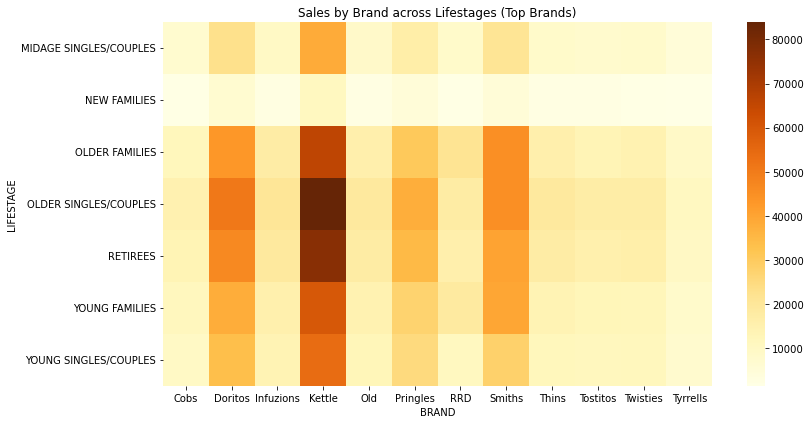

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure data is loaded
merged_df = pd.read_csv('merged_data.csv')

# Preconditions
if 'BRAND' not in merged_df.columns:
    raise ValueError("BRAND column not found. Create/standardise BRAND before running this cell.")

merged_df['LIFESTAGE'] = merged_df['LIFESTAGE'].fillna('Unknown')

# 1) Sales by BRAND x LIFESTAGE
brand_lifestage = (
    merged_df.groupby(['BRAND', 'LIFESTAGE'])
    .agg(
        TOTAL_SALES=('TOT_SALES', 'sum'),
        TOTAL_UNITS=('PROD_QTY', 'sum'),
        UNIQUE_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique'),
        TRANSACTIONS=('TXN_ID', 'nunique')
    )
    .reset_index()
)

# Shares within brand
brand_totals = brand_lifestage.groupby('BRAND')['TOTAL_SALES'].sum().reset_index(name='BRAND_TOTAL_SALES')
brand_lifestage = brand_lifestage.merge(brand_totals, on='BRAND', how='left')
brand_lifestage['SHARE_OF_BRAND'] = brand_lifestage['TOTAL_SALES'] / brand_lifestage['BRAND_TOTAL_SALES']

# 2) Dominating family (lifestage) per brand
TopFamilyPerBrand = (
    brand_lifestage.sort_values(['BRAND','TOTAL_SALES'], ascending=[True, False])
    .groupby('BRAND')
    .head(1)
    .reset_index(drop=True)
    .rename(columns={'LIFESTAGE':'DOMINATING_LIFESTAGE', 'TOTAL_SALES':'DOMINATING_SALES'})
)[['BRAND','DOMINATING_LIFESTAGE','DOMINATING_SALES','SHARE_OF_BRAND']]

print("Dominating family (lifestage) for each brand — top 20:")
print(TopFamilyPerBrand.head(20))
TopFamilyPerBrand.to_csv(OUT_DIR / 'top_family_per_brand.csv', index=False)

# 3) For each family: top brands by sales (with share within lifestage)
family_totals = brand_lifestage.groupby('LIFESTAGE')['TOTAL_SALES'].sum().reset_index(name='LIFESTAGE_TOTAL_SALES')
fam_brand = brand_lifestage.merge(family_totals, on='LIFESTAGE', how='left')
fam_brand['SHARE_WITHIN_LIFESTAGE'] = fam_brand['TOTAL_SALES'] / fam_brand['LIFESTAGE_TOTAL_SALES']

TopBrandsPerFamily = (
    fam_brand.sort_values(['LIFESTAGE','TOTAL_SALES'], ascending=[True, False])
    .groupby('LIFESTAGE')
    .head(5)
    .reset_index(drop=True)
)[['LIFESTAGE','BRAND','TOTAL_SALES','SHARE_WITHIN_LIFESTAGE']]

print("\nTop brands within each family (lifestage) — sample:")
print(TopBrandsPerFamily.head(30))
TopBrandsPerFamily.to_csv(OUT_DIR / 'top_brands_per_family.csv', index=False)

# 4) Heatmap: Sales by Brand across Lifestages (Top overall brands)
top_brands = brand_totals.sort_values('BRAND_TOTAL_SALES', ascending=False).head(12)['BRAND'].tolist()
pivot = brand_lifestage[brand_lifestage['BRAND'].isin(top_brands)].pivot_table(
    index='LIFESTAGE', columns='BRAND', values='TOTAL_SALES', fill_value=0
)
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='YlOrBr')
plt.title('Sales by Brand across Lifestages (Top Brands)')
plt.tight_layout()
plt.show()


### **Pack Size Analysis by Segment**

- Loads merged data and ensures BRAND column exists.
- Extracts PACK_SIZE from PROD_NAME using regex, handling grams and kilograms.
- Drops rows with missing pack size.
- Calculates average and median pack size by segment and saves to CSV.
- Creates pack size bands and counts units per band by segment.
- Plots a stacked bar chart for units by pack size band and segment.
- Saves additional data to CSV and updates merged_df.

Pack size stats by segment:
                 LIFESTAGE PREMIUM_CUSTOMER  AVG_PACK_SIZE  MEDIAN_PACK_SIZE
0   MIDAGE SINGLES/COUPLES           Budget     180.187450             170.0
1   MIDAGE SINGLES/COUPLES       Mainstream     184.582786             170.0
2   MIDAGE SINGLES/COUPLES          Premium     181.577897             170.0
3             NEW FAMILIES           Budget     181.161730             170.0
4             NEW FAMILIES       Mainstream     181.699355             170.0
5             NEW FAMILIES          Premium     181.286973             170.0
6           OLDER FAMILIES           Budget     182.487219             170.0
7           OLDER FAMILIES       Mainstream     182.175021             170.0
8           OLDER FAMILIES          Premium     181.468102             170.0
9    OLDER SINGLES/COUPLES           Budget     182.289183             170.0
10   OLDER SINGLES/COUPLES       Mainstream     181.642101             170.0
11   OLDER SINGLES/COUPLES          Premium     

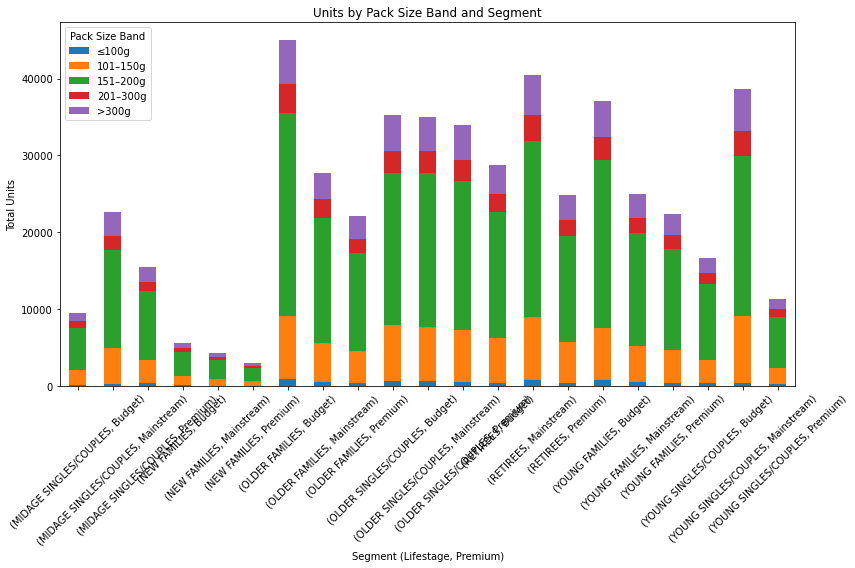

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load merged_df
merged_df = pd.read_csv('merged_data.csv')

# Ensure BRAND exists (from previous steps)
if 'BRAND' not in merged_df.columns:
    raise ValueError("BRAND column not found. Run the brand creation cell first.")

# Fill missing segments
merged_df['LIFESTAGE'] = merged_df['LIFESTAGE'].fillna('Unknown')
merged_df['PREMIUM_CUSTOMER'] = merged_df['PREMIUM_CUSTOMER'].fillna('Unknown')

# Extract PACK_SIZE from PROD_NAME (assuming format like "175g ..." or "150g")
def extract_pack_size(prod_name):
    match = re.search(r'(\d+)(g|kg)', prod_name, re.IGNORECASE)
    if match:
        num = int(match.group(1))
        unit = match.group(2).lower()
        if unit == 'kg':
            num *= 1000  # convert to grams
        return num
    return None

merged_df['PACK_SIZE'] = merged_df['PROD_NAME'].apply(extract_pack_size)

# Drop rows with missing pack size if any
merged_df = merged_df.dropna(subset=['PACK_SIZE'])

# 1) Average and median pack size by segment
pack_stats = merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PACK_SIZE'].agg(['mean', 'median']).reset_index()
pack_stats.columns = ['LIFESTAGE', 'PREMIUM_CUSTOMER', 'AVG_PACK_SIZE', 'MEDIAN_PACK_SIZE']
print("Pack size stats by segment:")
print(pack_stats)

# Save to CSV
pack_stats.to_csv(OUT_DIR / 'pack_size_stats_by_segment.csv', index=False)
# 2) Pack size bands
bins = [0, 100, 150, 200, 300, float('inf')]
labels = ['≤100g', '101–150g', '151–200g', '201–300g', '>300g']
merged_df['PACK_SIZE_BAND'] = pd.cut(merged_df['PACK_SIZE'], bins=bins, labels=labels, right=False)

# Count units per band by segment
units_by_band = (
    merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER', 'PACK_SIZE_BAND'])['PROD_QTY']
    .sum()
    .reset_index(name='TOTAL_UNITS')
)

print("\nUnits by pack size band and segment:")
print(units_by_band.head(50))

# Save full units by band
units_by_band.to_csv('units_by_pack_size_band.csv', index=False)
units_by_band.to_csv(OUT_DIR / 'units_by_pack_size_band.csv', index=False)
# Stacked bar chart: units by band per segment
pivot_units = units_by_band.pivot_table(index=['LIFESTAGE', 'PREMIUM_CUSTOMER'], columns='PACK_SIZE_BAND', values='TOTAL_UNITS', fill_value=0)
pivot_units.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Units by Pack Size Band and Segment')
plt.xlabel('Segment (Lifestage, Premium)')
plt.ylabel('Total Units')
plt.xticks(rotation=45)
plt.legend(title='Pack Size Band')
plt.tight_layout()
plt.show()

# Optional: Sales by band
sales_by_band = (
    merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER', 'PACK_SIZE_BAND'])['TOT_SALES']
    .sum()
    .reset_index(name='TOTAL_SALES')
)
sales_by_band.to_csv('sales_by_pack_size_band.csv', index=False)
sales_by_band.to_csv(OUT_DIR / 'sales_by_pack_size_band.csv', index=False)
# Save updated merged_df with PACK_SIZE
merged_df.to_csv('merged_data.csv', index=False)
                merged_df.to_csv(MERGED_CSV, index=False)

### **Sales Over Time Analysis**

- Loads merged data and ensures DATE is datetime.
- Aggregates total sales by month, prints summary, and plots a line chart.
- Aggregates by week, prints summary, and plots a line chart.
- Focuses on a key segment (YOUNG SINGLES/COUPLES, Budget), aggregates monthly sales, prints summary, and plots.
- Saves monthly sales data to CSV.

Monthly sales summary:
DATE
2018-07-01    165275.30
2018-08-01    158731.05
2018-09-01    160522.00
2018-10-01    164409.70
2018-11-01    160233.70
2018-12-01    167913.40
2019-01-01    162642.30
2019-02-01    150665.00
2019-03-01    166265.20
2019-04-01    159845.10
2019-05-01    157367.65
2019-06-01    160538.60
Freq: MS, Name: TOT_SALES, dtype: float64


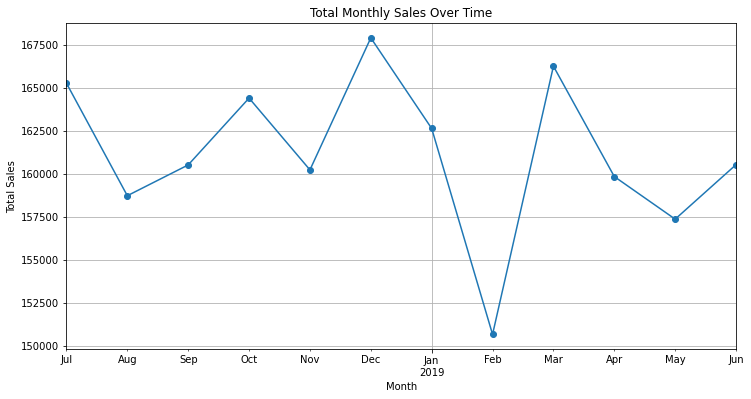


Weekly sales summary (first 10):
DATE
2018-06-25     5372.20
2018-07-02    37032.30
2018-07-09    37978.00
2018-07-16    37618.00
2018-07-23    36356.60
2018-07-30    37576.90
2018-08-06    37468.70
2018-08-13    32848.25
2018-08-20    36004.60
2018-08-27    36368.80
Freq: W-MON, Name: TOT_SALES, dtype: float64


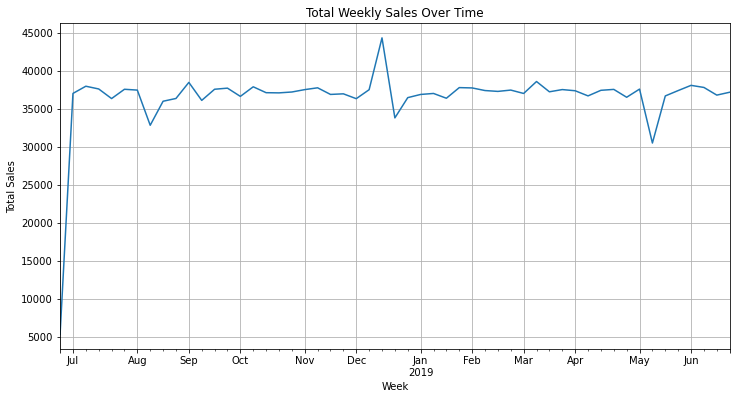


Monthly sales for key segment (YOUNG SINGLES/COUPLES, Budget):
DATE
2018-07-01    5178.40
2018-08-01    4693.35
2018-09-01    5278.40
2018-10-01    5156.70
2018-11-01    4856.60
2018-12-01    5585.70
2019-01-01    5274.30
2019-02-01    4569.80
2019-03-01    5346.90
2019-04-01    4965.30
2019-05-01    5127.85
2019-06-01    5108.30
Freq: MS, Name: TOT_SALES, dtype: float64


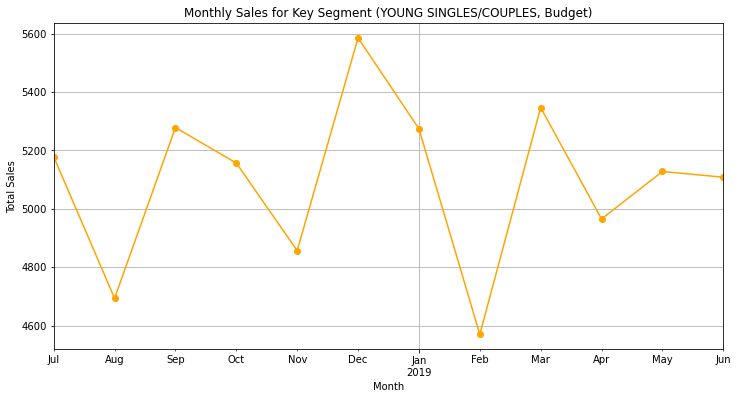

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load merged_df
merged_df = pd.read_csv('merged_data.csv')

# Ensure DATE is datetime
merged_df['DATE'] = pd.to_datetime(merged_df['DATE'])

# 1) Aggregate total sales by month
monthly_sales = merged_df.groupby(merged_df['DATE'].dt.to_period('M'))['TOT_SALES'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

print("Monthly sales summary:")
print(monthly_sales.head(12))

# Plot sales over time
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Total Monthly Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

# 2) Optionally, aggregate by week
weekly_sales = merged_df.groupby(merged_df['DATE'].dt.to_period('W'))['TOT_SALES'].sum()
weekly_sales.index = weekly_sales.index.to_timestamp()

print("\nWeekly sales summary (first 10):")
print(weekly_sales.head(10))

# Plot weekly sales
plt.figure(figsize=(12, 6))
weekly_sales.plot(kind='line')
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Week')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

# 3) Optionally, focus on a key segment (e.g., 'YOUNG SINGLES/COUPLES' and 'Budget')
key_segment = merged_df[(merged_df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (merged_df['PREMIUM_CUSTOMER'] == 'Budget')]
monthly_sales_key = key_segment.groupby(key_segment['DATE'].dt.to_period('M'))['TOT_SALES'].sum()
monthly_sales_key.index = monthly_sales_key.index.to_timestamp()

print("\nMonthly sales for key segment (YOUNG SINGLES/COUPLES, Budget):")
print(monthly_sales_key.head(12))

# Plot for key segment
plt.figure(figsize=(12, 6))
monthly_sales_key.plot(kind='line', marker='o', color='orange')
plt.title('Monthly Sales for Key Segment (YOUNG SINGLES/COUPLES, Budget)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

# Save monthly sales to CSV
monthly_sales.to_csv(OUT_DIR / 'monthly_sales.csv', index=True)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load merged_df (assuming all features are created)
merged_df = pd.read_csv(MERGED_CSV)

# Ensure necessary columns exist
if 'BRAND' not in merged_df.columns or 'PACK_SIZE' not in merged_df.columns:
    raise ValueError("BRAND and PACK_SIZE columns must be present. Run previous cells.")

# Fill missing segments
merged_df['LIFESTAGE'] = merged_df['LIFESTAGE'].fillna('Unknown')
merged_df['PREMIUM_CUSTOMER'] = merged_df['PREMIUM_CUSTOMER'].fillna('Unknown')

# Calculate price per gram (assuming PACK_SIZE is in grams)
merged_df['PRICE_PER_GRAM'] = merged_df['TOT_SALES'] / (merged_df['PROD_QTY'] * merged_df['PACK_SIZE'])

# 1. Who drives the category?
total_sales_by_segment = merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
total_sales_by_segment = total_sales_by_segment.sort_values('TOT_SALES', ascending=False)

avg_spend_by_segment = merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].mean().reset_index()
avg_spend_by_segment = avg_spend_by_segment.sort_values('TOT_SALES', ascending=False)

print("### 1. Who drives the category?")
print("Top segments by total sales:")
print(total_sales_by_segment.head(3))
print("\nTop segments by average spend:")
print(avg_spend_by_segment.head(3))

# Narrative
key_segments = total_sales_by_segment.head(3)['LIFESTAGE'] + ' ' + total_sales_by_segment.head(3)['PREMIUM_CUSTOMER']
print(f"\nKey customer segments: {', '.join(key_segments)}. They represent the highest sales and spend.")

# 2. What do they buy?
# Brands
top_brands_by_segment = (
    merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER', 'BRAND'])['TOT_SALES'].sum()
    .reset_index()
    .sort_values(['LIFESTAGE', 'PREMIUM_CUSTOMER', 'TOT_SALES'], ascending=[True, True, False])
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).head(3)
)

print("\n### 2. What do they buy?")
print("Top brands by segment:")
print(top_brands_by_segment.head(9))

# Pack sizes
pack_size_pref = merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER', 'PACK_SIZE_BAND'])['PROD_QTY'].sum().reset_index()
pack_size_pref = pack_size_pref.sort_values(['LIFESTAGE', 'PREMIUM_CUSTOMER', 'PROD_QTY'], ascending=[True, True, False])

print("\nPack size preferences by segment:")
print(pack_size_pref.head(15))

# 3. How do they behave on price?
avg_price_per_gram = merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PRICE_PER_GRAM'].mean().reset_index()
avg_price_per_gram = avg_price_per_gram.sort_values('PRICE_PER_GRAM', ascending=False)

print("\n### 3. How do they behave on price?")
print("Average price per gram by segment:")
print(avg_price_per_gram)

# 4. Where are the best commercial opportunities?
print("\n### 4. Where are the best commercial opportunities?")
print("- For top segments: Increase range and shelf space for preferred brands and pack sizes.")
print("- Targeted promotions: Multi-buy deals on large packs for families.")
print("- For smaller segments: Value options, smaller packs, entry-level brands.")
print("- Price strategy: Optimize pricing for premium segments; use promotions for budget groups.")

# 5. Summarise in a short strategic recommendation
print("\n### 5. Summarise in a short strategic recommendation:")
print("Focus growth efforts on top segments, who drive significant sales and prefer certain brands/pack sizes.")
print("Ensure assortment and promotions reflect these preferences.")
print("Use targeted value propositions to grow share among other segments.")


### 1. Who drives the category?
Top segments by total sales:
                LIFESTAGE PREMIUM_CUSTOMER  TOT_SALES
6          OLDER FAMILIES           Budget  168363.25
19  YOUNG SINGLES/COUPLES       Mainstream  157621.60
13               RETIREES       Mainstream  155677.05

Top segments by average spend:
                 LIFESTAGE PREMIUM_CUSTOMER  TOT_SALES
1   MIDAGE SINGLES/COUPLES       Mainstream   7.647284
19   YOUNG SINGLES/COUPLES       Mainstream   7.558339
14                RETIREES          Premium   7.456174

Key customer segments: OLDER FAMILIES Budget, YOUNG SINGLES/COUPLES Mainstream, RETIREES Mainstream. They represent the highest sales and spend.

### 2. What do they buy?
Top brands by segment:
                 LIFESTAGE PREMIUM_CUSTOMER    BRAND  TOT_SALES
10  MIDAGE SINGLES/COUPLES           Budget   Kettle    6736.20
5   MIDAGE SINGLES/COUPLES           Budget  Doritos    4553.60
16  MIDAGE SINGLES/COUPLES           Budget   Smiths    4251.30
34  MIDAGE SINGLES/C